# build up a basic understanding of the neural geometry of the task

- decision v. narrative trials (need all trial LSA and compare to LSS)
- characters
    - difference between
    - integration within
- dimensions
- affiliation & power locations 
- 2D locations (assuming orthogonality, optionally assuming a shared space)

for each analysis, come up with some simple schematic to help me understand better...

In [1]:
from utils import *

covariates   = ['sex', 'dx', 'ctq_score', 'missing_trials', 'memory_mean', 'fd_mean']
beta_cols    = ['angle_hpc_beta_2015', 'length_pcc_beta_2015']
subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares-striatum.pkl")

# rois = list(subject_data[18002]['roi_betas'].keys())
rois       = ['HPC-L', 'HPC-R', 'PCC-L', 'PCC-R']

def load_fmri_results(analysis):
    results  = pd.read_csv(f'../results/roi_analysis/{analysis}.csv')
    results  = results.merge(data, on='sub_id', how='left')
    return results

def plot_roi_results(analysis, est_name):
    
    results = load_fmri_results(analysis)
    results_main = results[results['sub_id'].isin(incl_subs)]
    results_tavares = results[results['sub_id'].isin(incl_subs_tavares)]
    
    fig, axs = plt.subplots(1, len(rois), figsize=(3*len(rois), 3))
    for sample, sample_results in {'Main': results_main, 'Tavares': results_tavares}.items():
        for i, roi in enumerate(rois): 
            ax = axs[i]
            roi_results = sample_results[sample_results['roi'] == roi]
            ax.set_title(roi)
            if sample == 'Main':
                ax = histplot(
                    roi_results,
                    x=est_name,
                    covariates=covariates,  
                    color=sample_colors[0],
                    bins=20,
                    ax=ax
                )
            elif sample == 'Tavares':
                ax = histplot(
                    roi_results,
                    x=est_name,
                    covariates=None,  
                    pval_y=0.88,
                    color=sample_colors[2],
                    bins=5,
                    ax=ax
                )
            else:
                ax = histplot(
                    roi_results,
                    x=est_name,
                    covariates=None,  
                    color='grey',
                    pval_y=0.825,
                    bins=15,
                    alpha=0.1,
                    ax=ax
                )
    plt.tight_layout()

    return results

def split_by_sample(df: pd.DataFrame, *, sub_col: str = "sub_id"):
    """
    Split a DataFrame into in-lab and Tavares samples based on subject IDs.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a subject ID column.
    sub_col : str, default "sub_id"
        Name of the subject ID column.

    Returns
    -------
    df_inlab : pd.DataFrame
        Rows where sub_id is in incl_subs.
    df_tavares : pd.DataFrame
        Rows where sub_id is in incl_subs_tavares.
    """
    if sub_col not in df.columns:
        raise KeyError(f"{sub_col} not found in DataFrame columns")

    df_inlab = df[df[sub_col].isin(incl_subs)].copy()
    df_tavares = df[df[sub_col].isin(incl_subs_tavares)].copy()

    return df_inlab, df_tavares

import statsmodels.formula.api as smf

def plot_interaction_effect(
    df: pd.DataFrame,
    *,
    formula: str,
    x: str,
    group: str,
    y: str,
    group_levels=None,          # e.g., [0, 1]
    x_grid=None,
    n_grid: int = 100,
    hold: dict | None = None,   # override covariate values held constant
    hold_strategy: str = "mean",# {"mean","median","mode","typical"}
    palette: str = "deep",
    color_map: dict | None = None,
    label_map: dict | None = None,
    figsize=(6, 5.5),
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    scatter_alpha: float = 0.9,
    scatter_edgecolor: str = "black",
    scatter_linewidth: float = 0.5,
    band_alpha: float = 0.18,
    line_width: float = 2.0,
    show: bool = True,
):
    """
    Fit OLS(formula) and plot an interaction as group-specific prediction lines (with mean CI bands)
    over x, plus scatter points colored by group.

    This is a generalized version of your LSAS × dx plot:
      - x is the continuous predictor (e.g., "lsas_av_score")
      - group is the moderator (e.g., "dx" coded 0/1 or categorical)
      - y is the outcome (e.g., "z_perm")

    Returns
    -------
    fig, ax, model, preds
      preds: dict[group_level] -> prediction summary_frame with x attached.
    """
    d = df.copy()

    # --- fit model ---
    model = smf.ols(formula, data=d).fit()

    # --- choose group levels ---
    if group_levels is None:
        # preserve categorical order if present; else sort unique
        if pd.api.types.is_categorical_dtype(d[group]):
            group_levels = list(d[group].cat.categories)
        else:
            group_levels = sorted(pd.unique(d[group].dropna()))
    group_levels = list(group_levels)

    # --- build x grid ---
    x_num = pd.to_numeric(d[x], errors="coerce").to_numpy(float)
    x_num = x_num[np.isfinite(x_num)]
    if x_grid is None:
        x_grid = np.linspace(float(x_num.min()), float(x_num.max()), int(n_grid))
    else:
        x_grid = np.asarray(x_grid, dtype=float)

    # --- holding covariates constant ---
    hold = {} if hold is None else dict(hold)

    def _typical_value(s: pd.Series):
        if pd.api.types.is_numeric_dtype(s):
            v = pd.to_numeric(s, errors="coerce")
            return float(np.nanmean(v))
        m = s.dropna()
        return m.mode().iloc[0] if len(m) else np.nan

    base = {}
    for col in d.columns:
        if col in {x, group, y}:
            continue
        if col in hold:
            base[col] = hold[col]
            continue

        s = d[col]
        if hold_strategy == "mean":
            base[col] = float(np.nanmean(pd.to_numeric(s, errors="coerce")))
        elif hold_strategy == "median":
            base[col] = float(np.nanmedian(pd.to_numeric(s, errors="coerce")))
        elif hold_strategy == "mode":
            m = s.dropna()
            base[col] = m.mode().iloc[0] if len(m) else np.nan
        else:  # "typical"
            base[col] = _typical_value(s)

    # --- colors / labels ---
    if color_map is None:
        pal = sns.color_palette(palette, n_colors=max(2, len(group_levels)))
        color_map = {g: pal[i] for i, g in enumerate(group_levels)}
    if label_map is None:
        label_map = {g: f"{group}={g}" for g in group_levels}

    # --- predict per group ---
    preds = {}
    for g in group_levels:
        grid = pd.DataFrame({**base, x: x_grid, group: g})
        sf = model.get_prediction(grid).summary_frame()
        sf[x] = x_grid
        preds[g] = sf

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)

    for g in group_levels:
        dd = d.loc[d[group] == g].copy()
        sns.scatterplot(
            data=dd,
            x=x,
            y=y,
            color=color_map[g],
            label=label_map[g],
            alpha=scatter_alpha,
            edgecolor=scatter_edgecolor,
            linewidth=scatter_linewidth,
            ax=ax,
        )

        ax.plot(
            x_grid,
            preds[g]["mean"].to_numpy(float),
            color=color_map[g],
            linewidth=line_width,
            label=f"{label_map[g]} (fit)",
        )

        ax.fill_between(
            x_grid,
            preds[g]["mean_ci_lower"].to_numpy(float),
            preds[g]["mean_ci_upper"].to_numpy(float),
            color=color_map[g],
            alpha=band_alpha,
            linewidth=0,
        )

    ax.set_title(title if title is not None else f"{x} × {group} interaction")
    ax.set_xlabel(xlabel if xlabel is not None else x)
    ax.set_ylabel(ylabel if ylabel is not None else y)

    # de-duplicate legend entries (scatter + fit)
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l in seen:
            continue
        seen.add(l)
        h2.append(h)
        l2.append(l)
    ax.legend(h2, l2, frameon=False)

    fig.tight_layout()
    if show:
        plt.show()

    return fig, ax, model, preds



In [2]:
from sklearn.metrics import pairwise_distances

def _strings_to_int_codes(vec):
    """
    Map a 1D array-like of strings (or mixed) to integer codes starting at 0.
    Returns (codes, mapping_dict).
    """
    s = pd.Series(vec)

    # If it's already numeric, just coerce.
    if pd.api.types.is_numeric_dtype(s):
        codes = pd.to_numeric(s, errors="coerce").to_numpy()
        return codes, None

    # Otherwise treat as categorical and map to 0..K-1
    cat = s.astype("string").fillna("<NA>").astype("category")
    codes = cat.cat.codes.to_numpy()  # -1 if NA; we replaced NA so should be >=0
    mapping = {k: int(v) for k, v in zip(cat.cat.categories.tolist(), range(len(cat.cat.categories)))}
    return codes, mapping

def _coerce_for_distances(X):
    """
    If X is 1D (single column / vector):
      - numeric => returns (n,1)
      - string/categorical => integer codes (n,1)
    If X is 2D:
      - ensures numeric (best-effort); if any non-numeric column, codes it column-wise.
    """
    arr = np.asarray(X)

    # 1D case
    if arr.ndim == 1:
        codes, mapping = _strings_to_int_codes(arr)
        X_out = np.asarray(codes, dtype=float)[:, None]
        return X_out, mapping

    # 2D case
    if arr.ndim != 2:
        raise ValueError(f"X must be 1D or 2D. Got shape {arr.shape}.")

    df = pd.DataFrame(arr)
    mappings = {}

    for j in df.columns:
        col = df[j]
        if pd.api.types.is_numeric_dtype(col):
            df[j] = pd.to_numeric(col, errors="coerce")
        else:
            codes, mapping = _strings_to_int_codes(col)
            df[j] = codes.astype(float)
            if mapping is not None:
                mappings[int(j)] = mapping

    X_out = df.to_numpy(dtype=float)
    return X_out, (mappings if mappings else None)

def plot_rdm(
    X,
    metric="cosine",
    *,
    palette="viridis",
    ax=None,
    figsize=(6, 5),
    square=True,
    annot=False,
    fmt=".2f",
    vmin=None,
    vmax=None,
    center=None,
    cbar=True,
    cbar_kws=None,
    xticklabels=False,
    yticklabels=False,
    title=None,
    preprocess_strings=True,
    **pairwise_kwargs,
):
    """
    Plot an RDM heatmap. If inputs are strings/categoricals, convert to integer codes
    starting at 0 before computing distances.

    Notes
    -----
    - If metric='precomputed', X must already be a square (n,n) distance matrix.
    - If X is a single column of strings, it becomes (n,1) integer codes then distances are computed.
    """
    X = np.asarray(X)

    if metric == "precomputed":
        if X.ndim != 2 or X.shape[0] != X.shape[1]:
            raise ValueError(
                f"When metric='precomputed', X must be a square (n,n) matrix. Got shape {X.shape}."
            )
        D = X.astype(float, copy=False)
        mappings = None
    else:
        if preprocess_strings:
            X_proc, mappings = _coerce_for_distances(X)
        else:
            if X.ndim == 1:
                X_proc = X[:, None]
            elif X.ndim == 2:
                X_proc = X
            else:
                raise ValueError(f"X must be 1D or 2D. Got shape {X.shape}.")
            mappings = None

        D = pairwise_distances(X_proc, metric=metric, **pairwise_kwargs)

    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise RuntimeError(f"Distance matrix is not square: {D.shape}")

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    sns.heatmap(
        D,
        ax=ax,
        cmap=palette,
        square=square,
        annot=annot,
        fmt=fmt,
        vmin=vmin,
        vmax=vmax,
        center=center,
        cbar=cbar,
        cbar_kws=cbar_kws,
        xticklabels=xticklabels,
        yticklabels=yticklabels,
    )

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel("Item")
    ax.set_ylabel("Item")

    # Return mapping(s) in case you want to interpret the codes later
    return ax


<h1 align='center'> What task structure can we discover? </h1>

<h1 align='center'> Character representations </h1>

## character representational differences
every ROI has this - is this confounded somehow? I Try to account for time and think I do...

In [ ]:
ax = plot_rdm(decision_trials['character_role_num'].values, metric='hamming', figsize=(3.5, 3));
ax.set_title("Character Role RDM");

In [ ]:
results = plot_roi_results('character-boundary', 'z')

### social anxiety might be related to more precise boundaries
a la Yael Niv's findings

see an almost right-tailed association for left hippocampus - which maybe we can justify based on Tavares' correlations with social anxiety?

also, when controlling for social anxiety, CUD is maybe associted with stronger differences

In [ ]:
print_df(run_regression('z ~ dx + sex + missing_trials + fd_mean', data=results[results['roi'].isin(['PCC-L'])]))

## convergence to a more and more self-similar character representation
I think this could reflect maybe some sort of integration

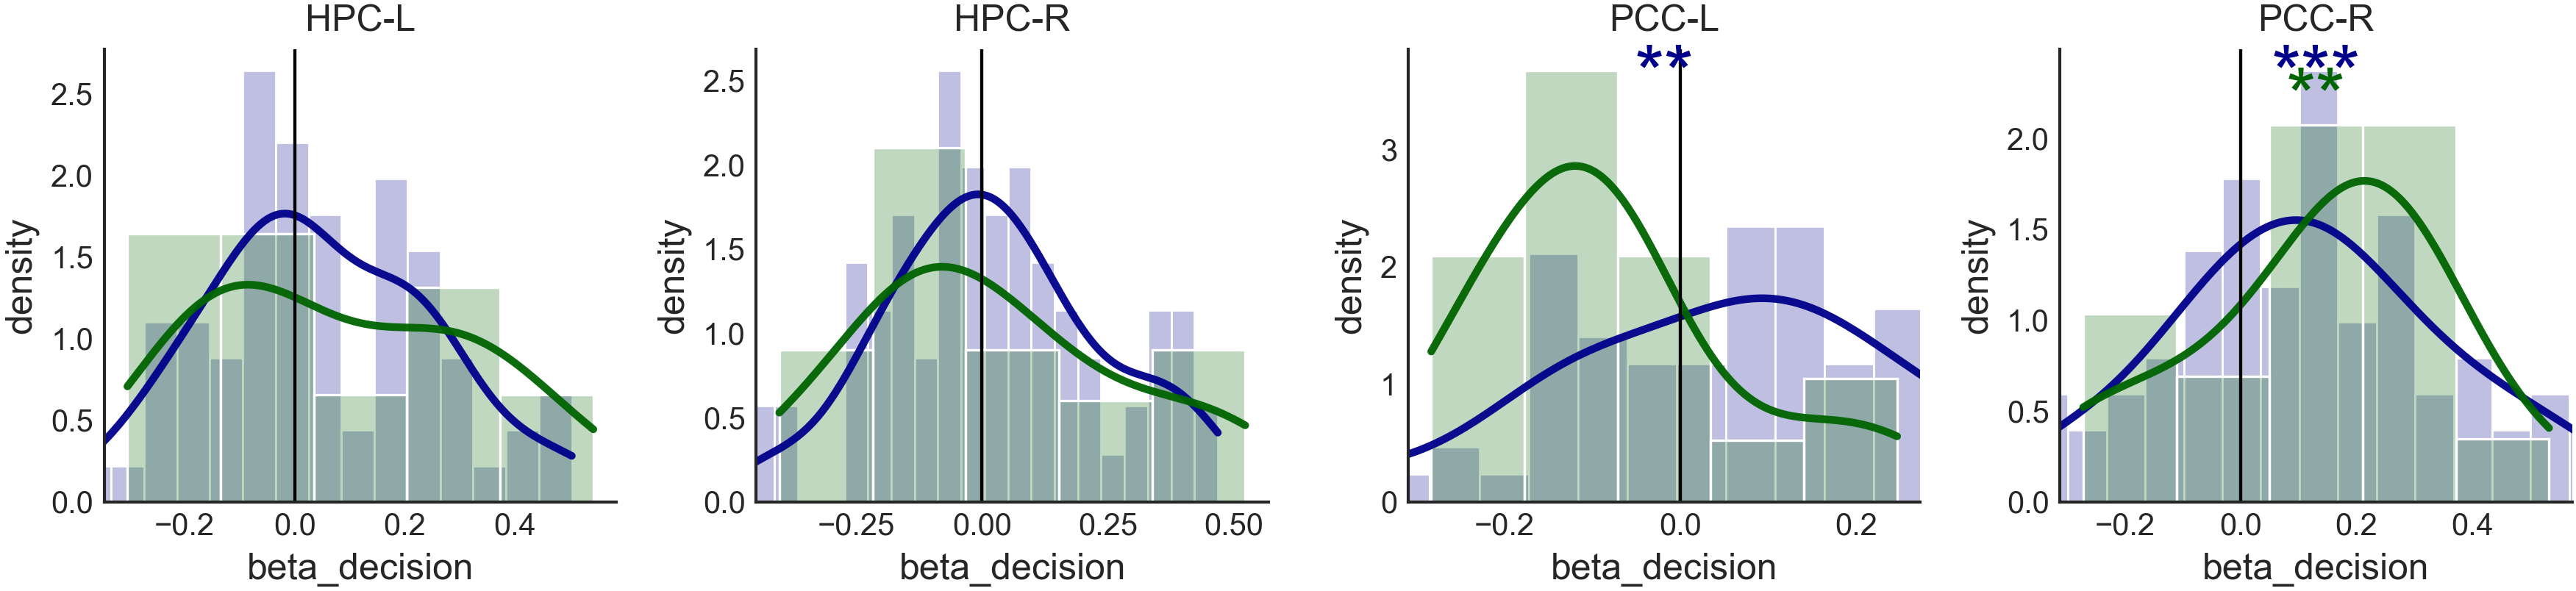

In [12]:
results = plot_roi_results('character-convergence', 'beta_decision')

# #------------ plot against memory

# results_pcc_left  = results[results['roi'].isin(['PCC-L'])]
# results_pcc_right = results[results['roi'].isin(['PCC-R'])]

# fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# fig.suptitle('Character convergence vs. Memory performance', fontsize=16, y=1.05)

# ax = axs[0]
# ax.set_title('Left PCC')
# regplot(results_pcc_left, x='mapping_score_distance_z', y='beta_decision', ax=ax)

# ax = axs[1]
# ax.set_title('Right PCC')
# regplot(results_pcc_right, x='mapping_score_distance_z', y='beta_decision', ax=ax);

### convergence and consistency
maybe the more similar the choices, the more the PCC representation converges on a similar pattern

## self-similarity and memory
need to stress test this: effect in PCC could just be that the region in general is more self-similar the more people pay attention, and it is attention that explains both memory and similarity

at minimum, it suggests representing structure -> memory

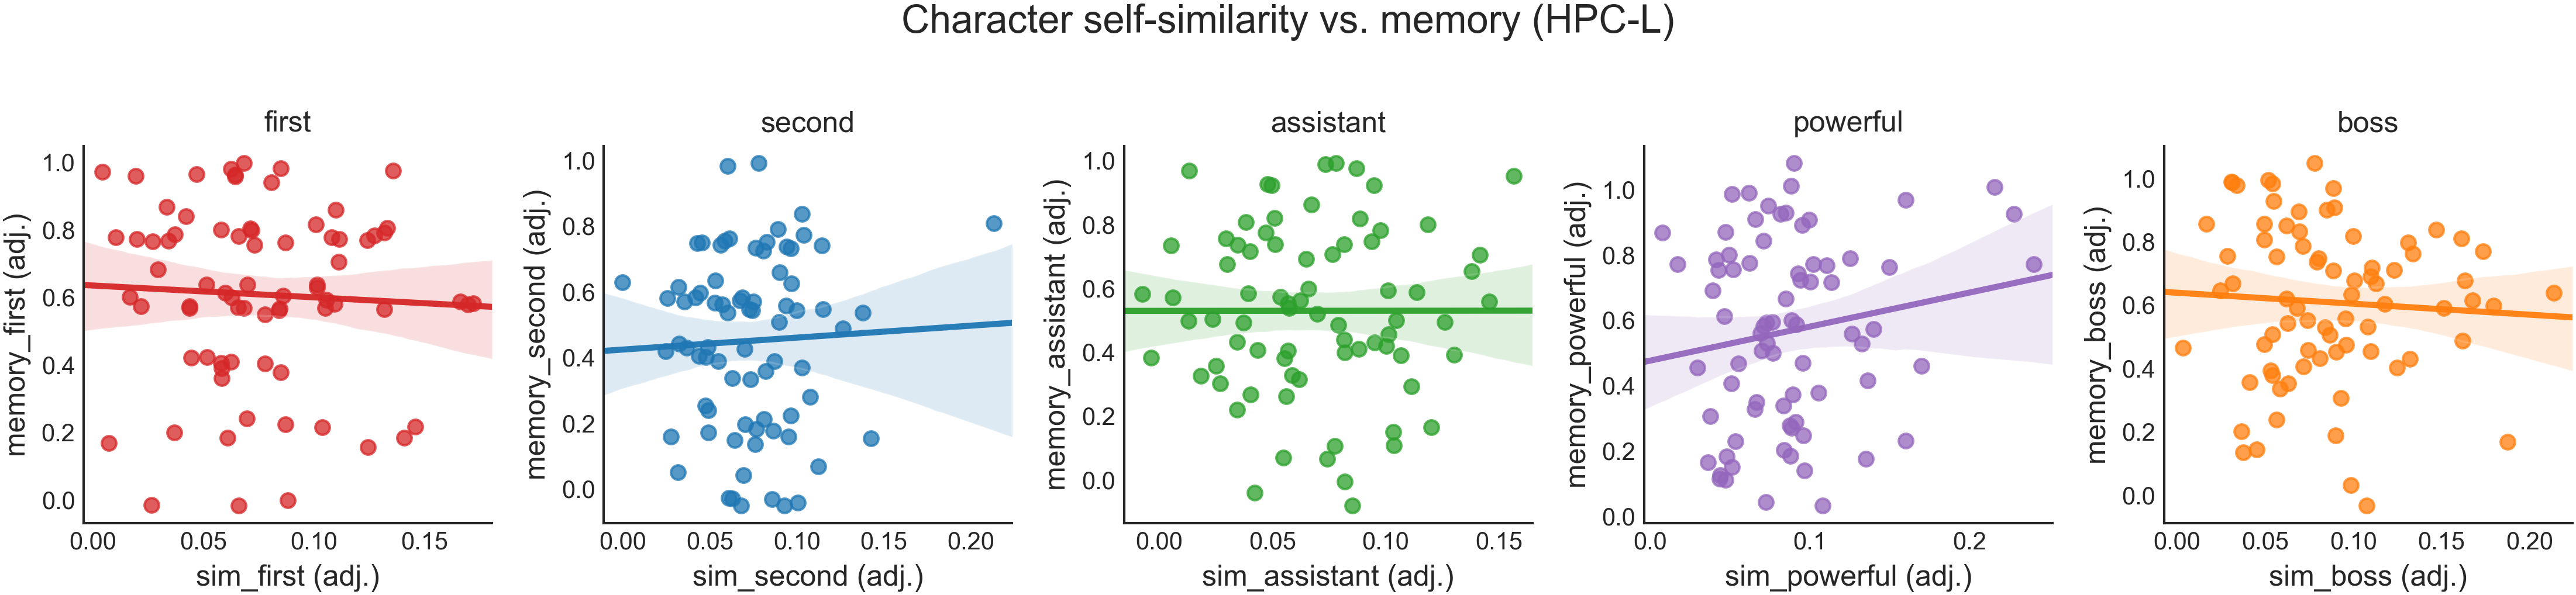

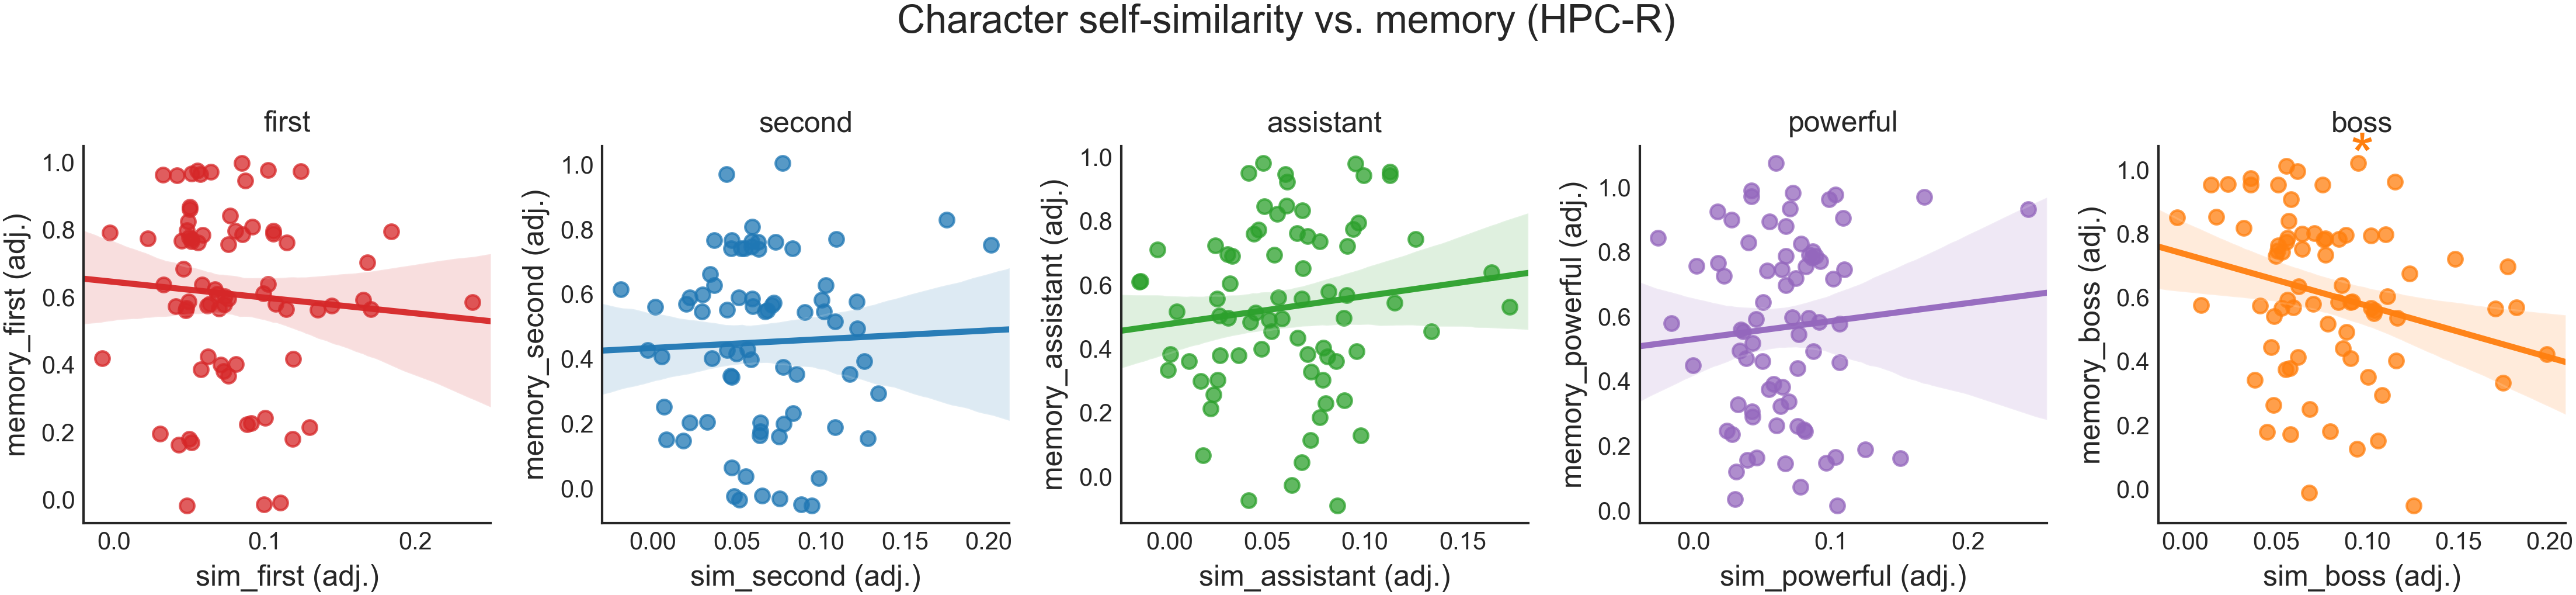

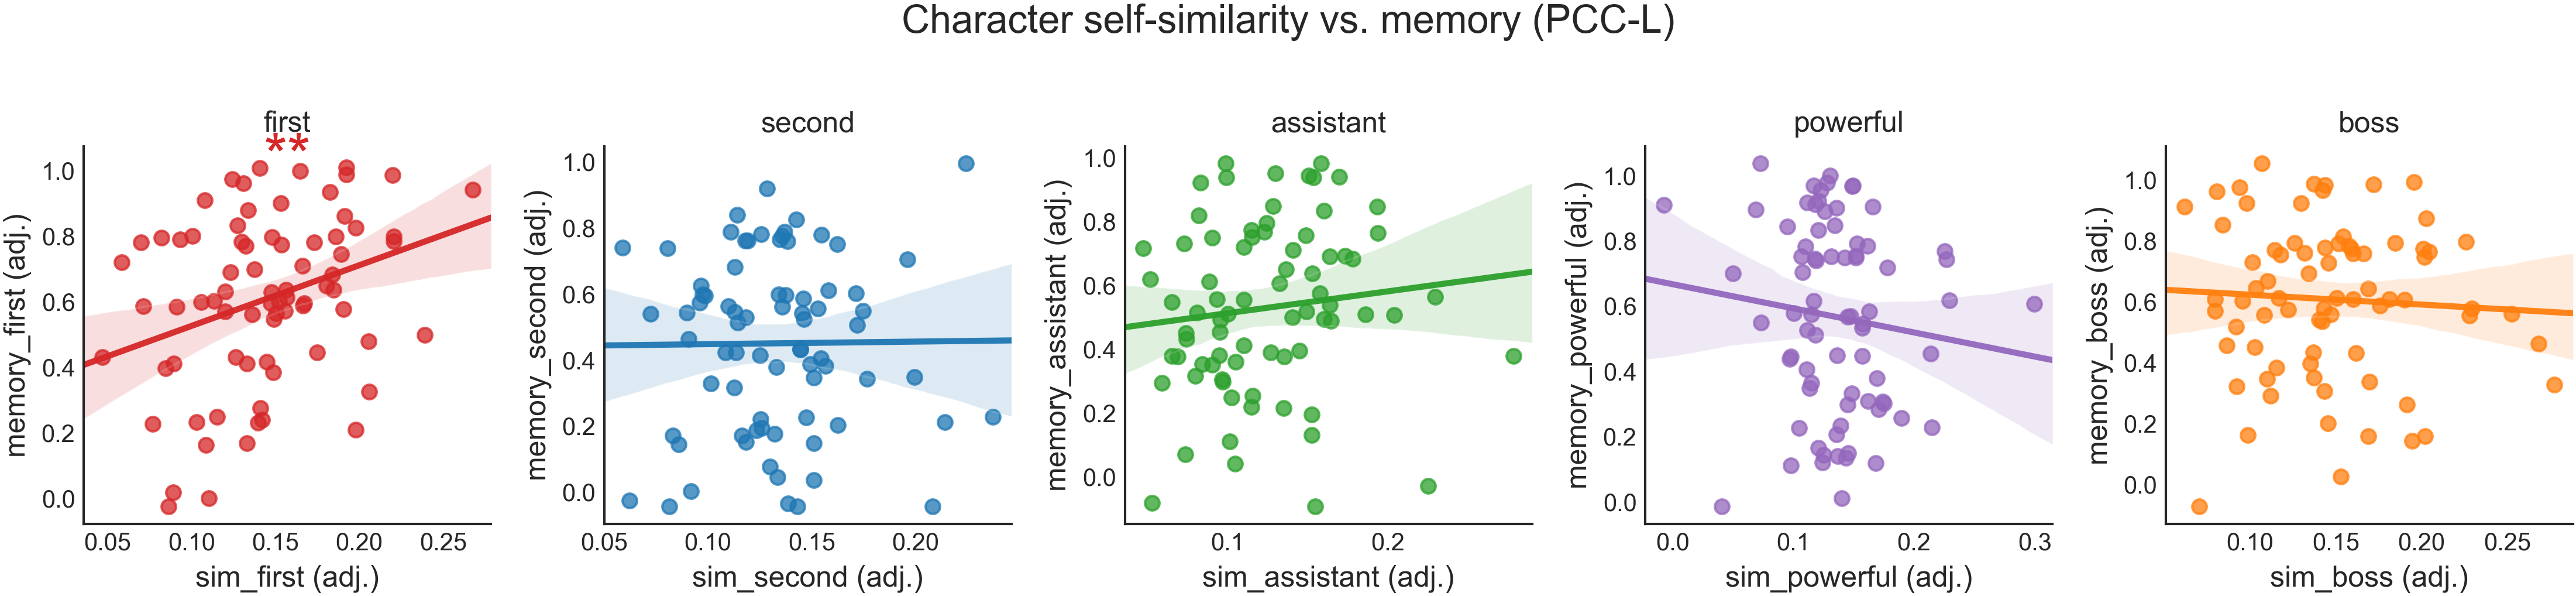

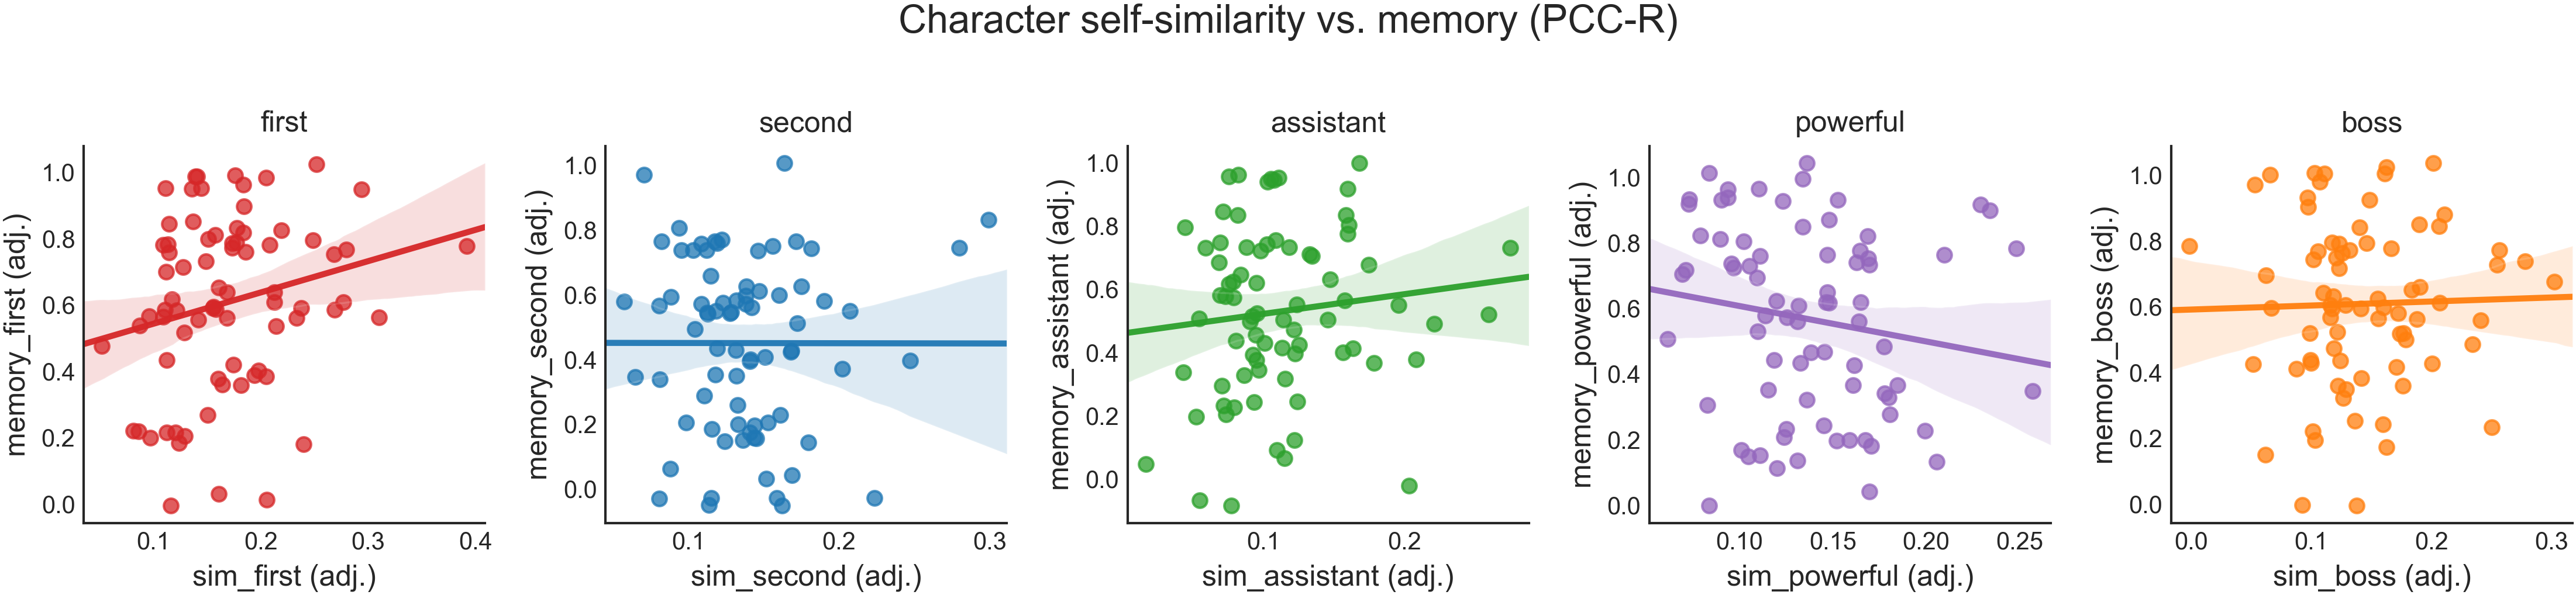

In [10]:
from scipy.spatial.distance import pdist
from sklearn.metrics import pairwise_distances

subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares-striatum.pkl")

for roi in ['HPC-L', 'HPC-R', 'PCC-L', 'PCC-R']:

    res = []
    for sub_id, sub_data in subject_data.items():
        betas = sub_data['roi_betas'][roi]
        betas = drop_neutral_trials(betas)
        by_char = organize_by_character(betas)

        # -----------------------------
        # A) within-character similarity
        # -----------------------------

        sim_within = []
        for b in by_char:
            sim_within.append(np.mean(1 - pdist(b, metric="cosine")))

        # -----------------------------
        # B) global similarity: mean similarity over ALL trial pairs
        # -----------------------------

        sim_global = np.mean(1 - pdist(betas, metric="cosine"))

        # -----------------------------
        # C) cross-character similarity: for each char, mean sim to all NON-that-char trials
        # -----------------------------

        sim_between = []
        for i, b in enumerate(by_char):
            others = np.vstack([by_char[j] for j in range(len(by_char)) if j != i])
            sim_between.append(np.mean(1 - pairwise_distances(b, others, metric="cosine")))

        res.append([sub_id, sim_global] + sim_within + sim_between)

    results = pd.DataFrame(
        res,
        columns=(["sub_id", "sim_global"]
                 + [f"sim_{char}" for char in CHARACTERS[:5]]
                 + [f"sim_between_{char}" for char in CHARACTERS[:5]])
    )
    results = results.merge(data, on="sub_id", how="left")

    # plot the results
    fig, axs = plt.subplots(1, 5, figsize=(15, 3.5))
    fig.suptitle(f'Character self-similarity vs. memory ({roi})', fontsize=16, y=1.01)
    for i, char in enumerate(CHARACTERS[:5]):
        ax = axs[i]
        ax.set_title(char)
        color = CHARACTER_COLORS[char]

        regplot(
            results,
            x=f"sim_{char}",
            y=f"memory_{char}",
            covariates=[f"sim_between_{char}", "missing_trials", "fd_mean"], 
            point_color=color,
            ax=ax,
        )

    plt.tight_layout()

<h1 align='center'> Dimension representations </h1>

- Different approaches more or less agree
- Decodability is not related to the correlation in behavior

In [ ]:
ax = plot_rdm(decision_trials['dimension'].values, figsize=(3.5, 3));
ax.set_title("Dimension RDM");

## similarity and seperation

In [ ]:
results = plot_roi_results('dimension-similarity', 'z')
results = plot_roi_results('axis-separation', 'z')

# # visualize all estimates
# results = plot_roi_results('dimension-similarity', 'within')
# results = plot_roi_results('dimension-similarity', 'between')
# results = plot_roi_results('dimension-similarity', 'diff')

### Age of use onset relates to dimension similarity
Really need to stress test this to try to narrow the interpretation some

In [ ]:
results = load_fmri_results('dimension-similarity')
print_df(run_regression('diff ~ coc_age_1st_use + sex + age_years + coc_dur_years + missing_trials + fd_mean',
                        data=results[results['roi'].isin(['PCC-R'])]))

results = load_fmri_results('axis-separation')
print_df(run_regression('z ~ coc_age_1st_use + sex + age_years + coc_dur_years + missing_trials + fd_mean',
                        data=results[results['roi'].isin(['PCC-R'])]))

In [ ]:
covariates = ['sex', 'ctq_score', 'missing_trials', 'memory_mean', 'fd_mean']
results_pcc_right = results[results['roi'].isin(['PCC-R'])]
histplot_groups(data=results_pcc_right, x='z', group_col='dx', bins=10, covariates=covariates);

## coding axes: how correlated are they?
I think this a follow-up in regions that show dimension decodability as a follow up geometry test (but in a non-circular manner)

I do not see this in the age of onset - but I do see it in ctq or lsas (no interaction w/ DX)

STRESS TEST
- need to show some reliability of the axes, and that decoding performance is not near chance

In [ ]:
results = load_fmri_results('axis-angles')
print_df(run_regression('raw_z ~ dx + ctq_score + missing_trials + memory_mean + fd_mean', 
                        data=results[results['roi'].isin(['PCC-L'])]))
print_df(run_regression('raw_z ~ dx + ctq_score + missing_trials + memory_mean + fd_mean', 
                        data=results[results['roi'].isin(['PCC-R'])]))

In [ ]:
# lsas avoidance 
print_df(run_regression('lsas_avoidance_score ~ affil_mean_mean + power_mean_mean + memory_mean', data=data))
print_df(run_regression('lsas_av_score ~ affil_mean_mean + power_mean_mean', data=data_tavares))
print_df(run_regression('lsas_av_score ~ affil_mean_mean + power_mean_mean + memory_mean', data=data_online))

<h1 align='center'>Choice representations</h1>

## choice direction similarity

this is going to be correlated with dimension, pretty strongly

In [ ]:
results = plot_roi_results('choice-similarity', 'z_choice_mismatch')
print_df(run_regression('z_choice_mismatch ~ dx * ctq_score + missing_trials', 
                        data=results[results['roi'].isin(['PCC-R'])]))

<h1 align='center'>Location representations</h1>

## 2D locations - change this to MR-RSA with running mean

In [ ]:
results_roi = results[results['roi'].isin(['PCC-R'])][['sub_id', 'z_location']]
results_roi = results_roi.merge(data_tavares, on='sub_id', how='left')
print_df(run_regression('angle_hpc_beta_2015 ~ z_location + missing_trials', data=results_roi))
print_df(run_regression('length_pcc_beta_2015 ~ z_location + missing_trials', data=results_roi))

## subspace angle similarity across characters

this incorporates 2D space projection
will def need to stress test this...
- is it just onset overlap?

this may be inflated by more similar behavior across characters... but then I suppose the difference across regions could still be useful?

In [ ]:
list(load_fmri_results('character-subspace-angles').columns)
results = plot_roi_results('character-subspace-angles', 'z_perm')

In [ ]:
roi_results_ = results[results['roi']=='HPC-L']
print_df(run_regression('z_perm ~ lsas_av_score + dx + sex + missing_trials + fd_mean + memory_mean', data=roi_results_))

results_main, results_tavares = split_by_sample(results[results['roi']=='PCC-R'], sub_col='sub_id')
fig, ax = plt.subplots(figsize=(5,4))
sns.regplot(data=results_tavares, 
            x='lsas_score', y='z_perm', color=sample_colors[2], ax=ax)
sns.regplot(data=results_main, 
            x='lsas_score', y='z_perm', color=sample_colors[0], ax=ax)


In [ ]:
roi = "HPC-L"
df_roi = results.loc[results["roi"] == roi].copy()
plot_interaction_effect(
    df_roi,
    formula="z_perm ~ affil_mean_mean + power_mean_mean + lsas_av_score * dx + sex + missing_trials + fd_mean + memory_mean",
    x="lsas_av_score",
    group="dx",
    y="z_perm",
    group_levels=[0, 1],
    title="LSAS × CUD interaction",
    xlabel="LSAS",
    ylabel="z_perm",
    label_map={0: "HC", 1: "CUD"},
);


## does across character similarity track their distance?

<h1 align='center'>Trajectories </h1>